In [1]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(vocab_size)

27


In [9]:
# build dataset for different splits
block_size = 3       # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8* len(words))
n2 = int(0.9* len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [35]:
# MLP revisited

n_embd = 10     # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # for fixin initial high loss error, dont set to 0, just small. -----|______ Making sure logits are closer to 0 for low initial loss
b2 = torch.randn(vocab_size, generator=g) * 0  # for fixin initial high loss error  ----------------------------------------------|
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))    # number of total parameters
for p in parameters:
    p.requires_grad = True

11897


In [ ]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch contruct
    index = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g) # generating a tuple of numbers between 0 and X.shape[0]
    Xb, Yb = Xtr[index], Ytr[index]  # batch X, Y

    # forward pass
    emb = C[Xtr[index]] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1          # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2     # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01   # step learning decay
    for p in parameters:
        p.data += -lr * p.grad    # for finding optimal lr, use lr instead 0.1 
    
    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3148
  10000/ 200000: 2.6505
  20000/ 200000: 2.4705
  30000/ 200000: 2.0266
  40000/ 200000: 2.1797
  50000/ 200000: 2.4072
  60000/ 200000: 2.2316
  70000/ 200000: 2.0701
  80000/ 200000: 2.0010
  90000/ 200000: 2.0439
 100000/ 200000: 2.4564
 110000/ 200000: 2.2124
 120000/ 200000: 2.1843
 130000/ 200000: 2.2414
 140000/ 200000: 2.1447
 150000/ 200000: 2.2837
 160000/ 200000: 2.0286
 170000/ 200000: 2.0146
 180000/ 200000: 2.2178
 190000/ 200000: 2.0372


(array([2217.,  139.,   94.,   79.,   52.,  100.,   35.,   16.,   30.,
          33.,   27.,   19.,   18.,   14.,   15.,   33.,   28.,    7.,
          35.,   13.,   12.,   22.,   26.,   20.,   24.,   25.,    8.,
          15.,   11.,   33.,   20.,   11.,   13.,   12.,   15.,   24.,
          22.,   22.,   29.,   18.,   30.,   26.,   34.,   35.,   74.,
          65.,   82.,   56.,  138., 2474.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

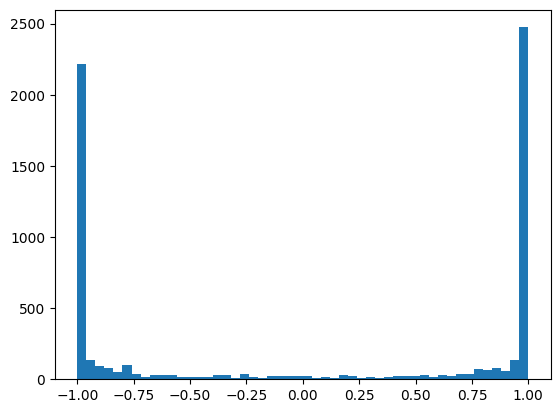

In [ ]:
# iniital values of activation of hidden states (h)
h
plt.hist(h.view(-1).tolist(), 50)
# a lot of em are 1, -1. Tanh is a squashing function, compressing values into [0, 1]
# this has an effect of grad of tanh during backpropagate comes very close to 0
# you can change the input values but minimal change in output of tanh, in the flat region
# tanh is inactive, back gradient just get destroyed.
# sometimes we have dead neuron, no example would activate it. no learning.

(array([  1.,   0.,   0.,   1.,   7.,   3.,  11.,  14.,  11.,  19.,  36.,
         45.,  55.,  93.,  99., 123., 252., 238., 323., 313., 344., 356.,
        505., 479., 465., 382., 321., 282., 337., 283., 244., 210., 126.,
        101., 106.,  62.,  57.,  29.,  16.,  15.,   6.,  15.,   8.,   3.,
          1.,   0.,   2.,   0.,   0.,   1.]),
 array([-25.30010605, -24.22374947, -23.14739288, -22.0710363 ,
        -20.99467972, -19.91832314, -18.84196655, -17.76560997,
        -16.68925339, -15.6128968 , -14.53654022, -13.46018364,
        -12.38382706, -11.30747047, -10.23111389,  -9.15475731,
         -8.07840073,  -7.00204414,  -5.92568756,  -4.84933098,
         -3.7729744 ,  -2.69661781,  -1.62026123,  -0.54390465,
          0.53245193,   1.60880852,   2.6851651 ,   3.76152168,
          4.83787827,   5.91423485,   6.99059143,   8.06694801,
          9.1433046 ,  10.21966118,  11.29601776,  12.37237434,
         13.44873093,  14.52508751,  15.60144409,  16.67780067,
         17.754157

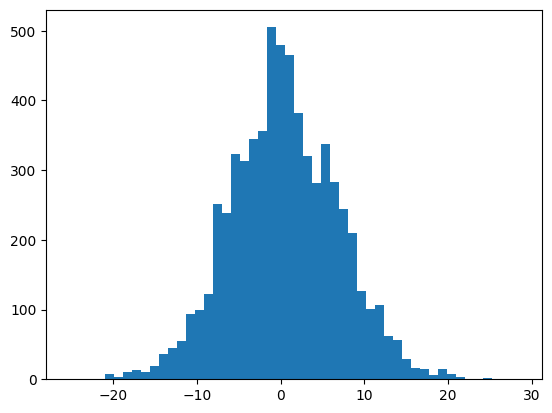

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50)  # very broad values

tensor([[-1.0000,  0.9252, -0.3721,  ...,  0.4169,  1.0000,  1.0000],
        [-0.9944, -0.9996, -1.0000,  ..., -0.9999,  1.0000,  0.6736],
        [ 1.0000, -1.0000, -0.9426,  ..., -0.9998, -0.7021, -0.9991],
        ...,
        [-1.0000,  0.9999, -1.0000,  ...,  1.0000, -1.0000,  0.0885],
        [-1.0000,  0.9252, -0.3721,  ...,  0.4169,  1.0000,  1.0000],
        [-0.9998, -0.9853,  1.0000,  ..., -1.0000,  0.9997,  1.0000]],
       grad_fn=<TanhBackward0>)

In [28]:
# very high initialization loss, the probability distribution should be uniform (1/27), but isnt. Some characters have very high probability, some don't

In [ ]:
# 4D example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4) * 10  # need not be low, just equal would also be fine, because of normalization 
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

# when logits take extreme values then they have false over confidence

(tensor([-14.0727,   1.2267,   0.0745,  14.6759]),
 tensor([3.2705e-13, 1.4423e-06, 4.5569e-07, 1.0000e+00]),
 tensor(14.6015))

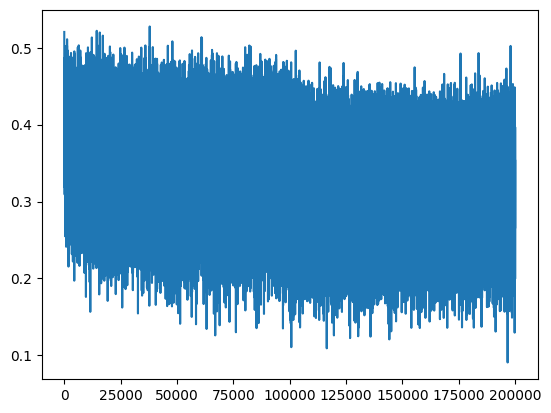

In [36]:
plt.plot(lossi)

In [ ]:
@torch.no_grad()  # disabled gradient tracking for efficiency
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2                # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.133023262023926
val 2.1311235427856445


In [ ]:
g = torch.Generator().manual_seed()
